# MobileNetV2 – Classificação CPRE (v8)

**Única diferença face ao v4 (F1=0.5558):**
- ERCPDataset carrega imagens como **RGB** com PIL antes dos transforms MONAI
- Todo o resto é igual ao v4

Objetivo: isolar o impacto do carregamento RGB mantendo tudo o resto constante.

In [22]:
!pip install -q livelossplot monai torchmetrics opencv-python-headless tqdm

In [23]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    raise RuntimeError('GPU não encontrada! Ativa em Settings > Accelerator > GPU T4 x2')

Dispositivo: cuda
GPU: Tesla T4


## 1. Pré-processamento CLAHE offline
Aplica CLAHE a todas as imagens e guarda numa nova pasta `dataset_clahe/`.
Só precisa de correr **uma vez**.

In [28]:
import os
import cv2
import shutil
from tqdm import tqdm

# --- 1. CAMINHOS (Ajusta o INPUT_DIR se o nome do teu dataset for outro) ---
INPUT_DIR  = '/kaggle/input/datasets/filipapereira30/dataset-2/MIQR-CC-Dataset/training/dataset'
OUTPUT_DIR = '/kaggle/working/dataset_clahe'

# --- 2. LIMPEZA E CRIAÇÃO ---
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = ['train', 'val', 'test']

# --- 3. PROCESSAMENTO ---
for split in splits:
    split_input  = os.path.join(INPUT_DIR, split)
    split_output = os.path.join(OUTPUT_DIR, split)
    
    # Verifica se a pasta de entrada existe antes de tentar listar
    if not os.path.exists(split_input):
        print(f"⚠️ Pasta não encontrada no input: {split_input}")
        continue
        
    os.makedirs(split_output, exist_ok=True)

    for cls in os.listdir(split_input):
        input_class_dir  = os.path.join(split_input, cls)
        output_class_dir = os.path.join(split_output, cls)
        os.makedirs(output_class_dir, exist_ok=True)

        image_files = [f for f in os.listdir(input_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f'A processar {split}/{cls}...')

        for image_name in tqdm(image_files):
            input_path  = os.path.join(input_class_dir, image_name)
            output_path = os.path.join(output_class_dir, image_name)

            img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue

            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img_clahe = clahe.apply(img)
            cv2.imwrite(output_path, img_clahe)

print("✅ Tudo pronto!")

A processar train/Stricture...


100%|██████████| 255/255 [00:03<00:00, 73.51it/s]


A processar train/Lithiasis...


100%|██████████| 505/505 [00:06<00:00, 72.80it/s]


A processar train/Biliary_Leaks...


...

A processar test/Biliary_Leaks...


100%|██████████| 17/17 [00:00<00:00, 67.32it/s]


A processar test/Normal...


100%|██████████| 43/43 [00:00<00:00, 62.57it/s]

✅ Tudo pronto!


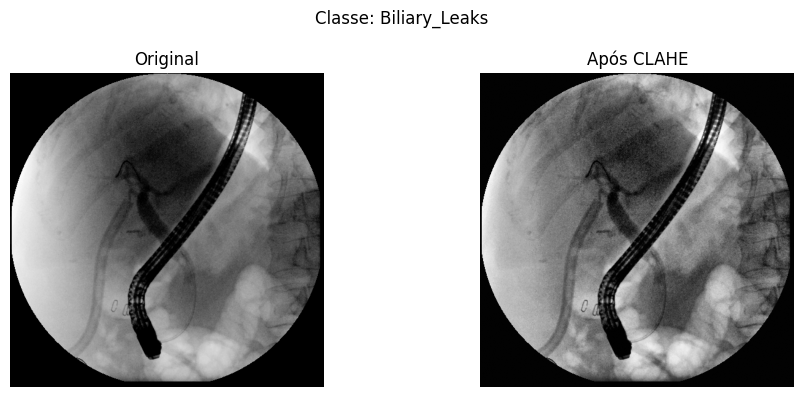

In [29]:
# Visualização: original vs CLAHE
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

sample_class = os.listdir(os.path.join(OUTPUT_DIR, 'train'))[0]
sample_file  = os.listdir(os.path.join(OUTPUT_DIR, 'train', sample_class))[0]

orig_path  = os.path.join(INPUT_DIR,  'train', sample_class, sample_file)
clahe_path = os.path.join(OUTPUT_DIR, 'train', sample_class, sample_file)

orig  = cv2.imread(orig_path,  cv2.IMREAD_GRAYSCALE)
clahe_img = cv2.imread(clahe_path, cv2.IMREAD_GRAYSCALE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(orig,      cmap='gray'); ax1.set_title('Original');    ax1.axis('off')
ax2.imshow(clahe_img, cmap='gray'); ax2.set_title('Após CLAHE'); ax2.axis('off')
plt.suptitle(f'Classe: {sample_class}', fontsize=12)
plt.tight_layout(); plt.show()

## 2. Imports e Configuração

In [30]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import seaborn as sns
import random, time, warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchmetrics.classification import MulticlassF1Score

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst,
                               Resize, RandZoom, RandAdjustContrast, RandGaussianNoise,
                               RandRotate, RandFlip, RandAffine, ToTensor, Compose,
                               NormalizeIntensity, Lambda)
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#insta

In [31]:
model_path = '/kaggle/working/MIA_AP_my_models'
os.makedirs(model_path, exist_ok=True)

# Aponta para o dataset com CLAHE já aplicado
base_dir = OUTPUT_DIR

def get_versioned_model_name(base_path):
    base = Path(base_path)
    ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
    return str(base.parent / f'{base.stem}_{ts}{base.suffix}')

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS_P1  = 10
EPOCHS_P2  = 60
LR_P1      = 1e-3
LR_P2      = 1e-4
PATIENCE   = 15
SEED       = 42
CW_POWER   = 0.5

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'base_dir: {base_dir}')
print(f'Config OK | GPU | IMG={IMG_SIZE} | BATCH={BATCH_SIZE}')

base_dir: /kaggle/working/dataset_clahe
Config OK | GPU | IMG=224 | BATCH=32


## 3. Dataset

In [32]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
for phase in phases:
    for i, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, phase, cname)
        imgs = [os.path.join(cdir, f) for f in os.listdir(cdir) if f.lower().endswith(valid_exts)]
        data[phase]['images'].extend(imgs)
        data[phase]['labels'].extend([i] * len(imgs))

for phase in phases:
    labels = data[phase]['labels']
    print(f'\n{phase.upper()} – {len(labels)} imagens')
    for i, c in enumerate(class_names):
        n = labels.count(i)
        print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


## 4. Transforms
Sem Lambda CLAHE — as imagens já vêm pré-processadas.

In [33]:
def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    RandFlip(spatial_axis=0, prob=0.4),
    RandFlip(spatial_axis=1, prob=0.4),
    RandRotate(range_x=20, prob=0.5),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    RandAffine(shear_range=0.1, prob=0.3),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)
print('Transforms definidos (sem CLAHE inline — já aplicado offline).')

Transforms definidos (sem CLAHE inline — já aplicado offline).


In [34]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        # v8: carrega como RGB e converte para array numpy antes do MONAI
        from PIL import Image as PILImage
        import numpy as np
        img_pil = PILImage.open(self.image_files[idx]).convert("RGB")
        img_np  = np.array(img_pil)          # (H, W, 3) uint8
        img_t   = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  # (3, H, W)
        # Aplica só resize + augmentação (sem LoadImage, sem EnsureChannelFirst)
        from torchvision import transforms as T
        resize = T.Resize((IMG_SIZE, IMG_SIZE))
        img_t  = resize(img_t)
        # Normalização ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_t = (img_t - mean) / std
        return img_t, self.labels[idx]


# Transforms MONAI só para val (sem augmentação aleatória no Dataset)
# O train usa augmentação inline no __getitem__ abaixo
class ERCPDatasetTrain(Dataset):
    def __init__(self, image_files, labels):
        self.image_files = image_files
        self.labels      = labels
        self.aug = T_train

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        from PIL import Image as PILImage
        img = PILImage.open(self.image_files[idx]).convert("RGB")
        return self.aug(img), self.labels[idx]


import torchvision.transforms as T_tv

T_train = T_tv.Compose([
    T_tv.Resize((IMG_SIZE, IMG_SIZE)),
    T_tv.RandomHorizontalFlip(p=0.4),
    T_tv.RandomVerticalFlip(p=0.4),
    T_tv.RandomRotation(degrees=20),
    T_tv.RandomAffine(degrees=0, shear=10),
    T_tv.ColorJitter(contrast=0.3, brightness=0.2),
    T_tv.ToTensor(),
    T_tv.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

T_val = T_tv.Compose([
    T_tv.Resize((IMG_SIZE, IMG_SIZE)),
    T_tv.ToTensor(),
    T_tv.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ERCPDatasetVal(Dataset):
    def __init__(self, image_files, labels):
        self.image_files = image_files
        self.labels      = labels
    def __len__(self): return len(self.image_files)
    def __getitem__(self, idx):
        from PIL import Image as PILImage
        img = PILImage.open(self.image_files[idx]).convert("RGB")
        return T_val(img), self.labels[idx]


# Class weights suavizados
train_labels_np = np.array(data['train']['labels'])
cw_raw    = compute_class_weight('balanced', classes=np.arange(num_class), y=train_labels_np)
cw_smooth = cw_raw ** CW_POWER
cw_smooth = cw_smooth / cw_smooth.mean()
cw_tensor = torch.tensor(cw_smooth, dtype=torch.float32).to(device)

print('Class weights (suavizados):')
for i, (raw, smooth) in enumerate(zip(cw_raw, cw_smooth)):
    print(f'  {class_names[i]}: {raw:.3f} → {smooth:.3f}')

train_ds = ERCPDatasetTrain(data['train']['images'], data['train']['labels'])
val_ds   = ERCPDatasetVal(data['val']['images'],   data['val']['labels'])
test_ds  = ERCPDatasetVal(data['test']['images'],  data['test']['labels'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Class weights (suavizados):
  Biliary_Leaks: 2.425 → 1.393
  Lithiasis: 0.528 → 0.650
  Normal: 1.354 → 1.041
  Stricture: 1.046 → 0.915

Train: 1067 | Val: 234 | Test: 267


## 5. Modelo, Loss e Treino

In [35]:
def build_model(freeze_backbone=True):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_class)
    )
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    return model.to(device)

model     = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis (fase 1): {trainable:,}')

Parâmetros treináveis (fase 1): 328,964


In [36]:
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

loss_fn = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.1)
print('Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)')

Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)


In [37]:
def train_phase(model, train_dl, val_dl, optimizer, scheduler,
                epochs, save_path, patience, use_mixup=False, phase_name=''):

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()
    liveloss   = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{save_path}_{phase_name}.png')])
    best_f1, best_epoch, no_improve = -1.0, -1, 0

    print(f'\n{"="*55}')
    print(f' {phase_name}  |  epochs={epochs}  |  mixup={use_mixup}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        y_pred_all = torch.tensor([], dtype=torch.float32, device=device)
        y_all      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            if use_mixup:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            y_pred_all = torch.cat([y_pred_all, outputs.detach()], dim=0)
            y_all      = torch.cat([y_all, labels], dim=0)

        epoch_loss = (running_loss / len(train_dl.dataset)).item()
        train_f1   = f1_metric(y_pred_all.argmax(dim=1), y_all).item()

        model.eval()
        val_loss = 0.0
        y_pred_v = torch.tensor([], dtype=torch.float32, device=device)
        y_v      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs  = model(inputs)
                val_loss += loss_fn(outputs, labels).detach() * inputs.size(0)
                y_pred_v  = torch.cat([y_pred_v, outputs], dim=0)
                y_v       = torch.cat([y_v, labels],       dim=0)

        val_epoch_loss = (val_loss / len(val_dl.dataset)).item()
        val_f1         = f1_metric(y_pred_v.argmax(dim=1), y_v).item()

        y_onehot   = [to_onehot(i) for i in decollate_batch(y_v, detach=False)]
        y_pred_act = [act(i) for i in decollate_batch(y_pred_v)]
        auc_metric(y_pred_act, y_onehot)
        auc_val = auc_metric.aggregate()
        auc_metric.reset()

        liveloss.update({'loss': epoch_loss, 'val_loss': val_epoch_loss,
                         'F1': train_f1,     'val_F1': val_f1})
        liveloss.send()
        scheduler.step()

        print(f'Ep {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  '
              f'val_loss={val_epoch_loss:.4f}  F1={train_f1:.4f}  '
              f'val_F1={val_f1:.4f}  AUC={auc_val:.4f}')

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch+1
            torch.save(model.state_dict(), save_path)
            print(f'  ✔ Melhor modelo guardado (val F1={best_f1:.4f})')
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'Early stopping ep {epoch+1}. Melhor: {best_epoch}, F1={best_f1:.4f}')
            break

    print(f'Fase concluída – melhor val F1: {best_f1:.4f}')
    return best_f1

## 6. Treino – Fase 1: Feature Extraction

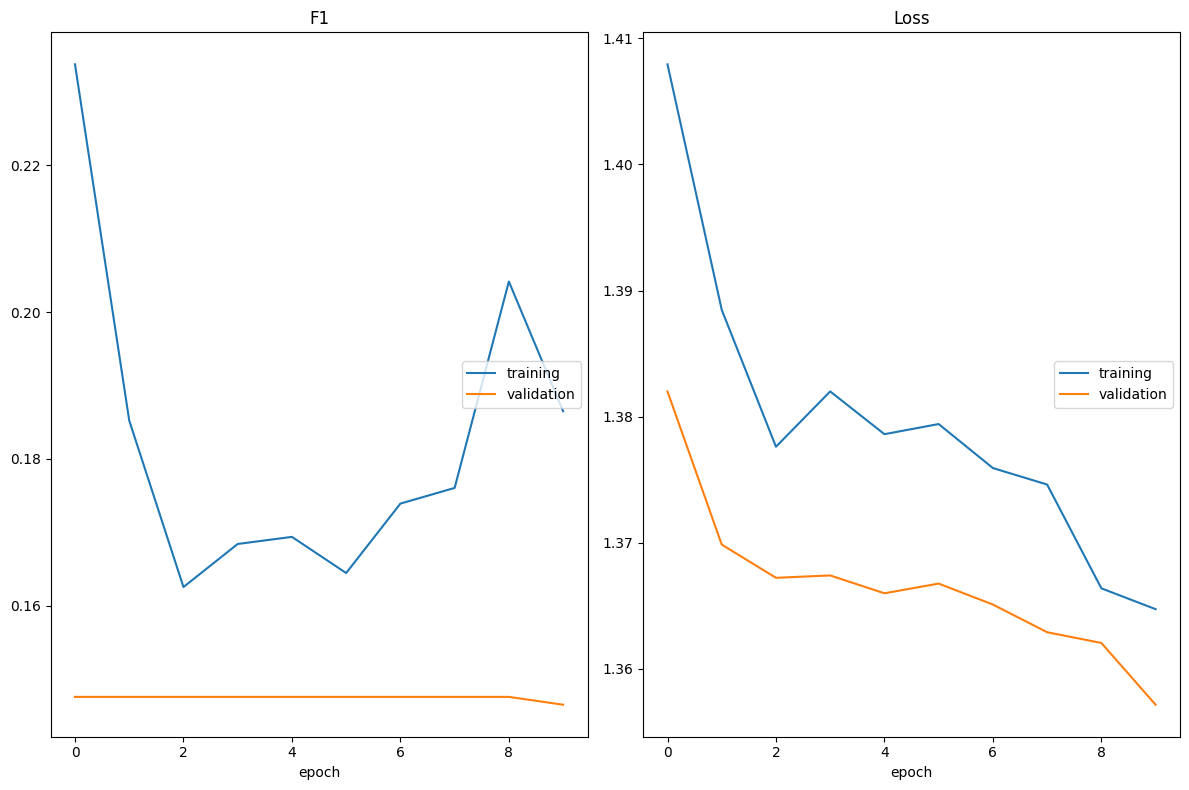

Ep  10/10  loss=1.3647  val_loss=1.3572  F1=0.1865  val_F1=0.1465  AUC=0.6070
Fase concluída – melhor val F1: 0.1476
Tempo fase 1: 103.2s


In [38]:
set_seed(SEED)
model      = build_model(freeze_backbone=True)
model_name = get_versioned_model_name(f'{model_path}/mobilenet_v2_v4.pth')

opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=1e-4
)
sch1 = torch.optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=LR_P1,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_P1
)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt1, sch1, EPOCHS_P1, model_name,
            patience=PATIENCE, use_mixup=False,
            phase_name='Fase1_FeatureExtraction')
print(f'Tempo fase 1: {time.perf_counter()-t0:.1f}s')

## 7. Treino – Fase 2: Fine-tuning completo + Mixup

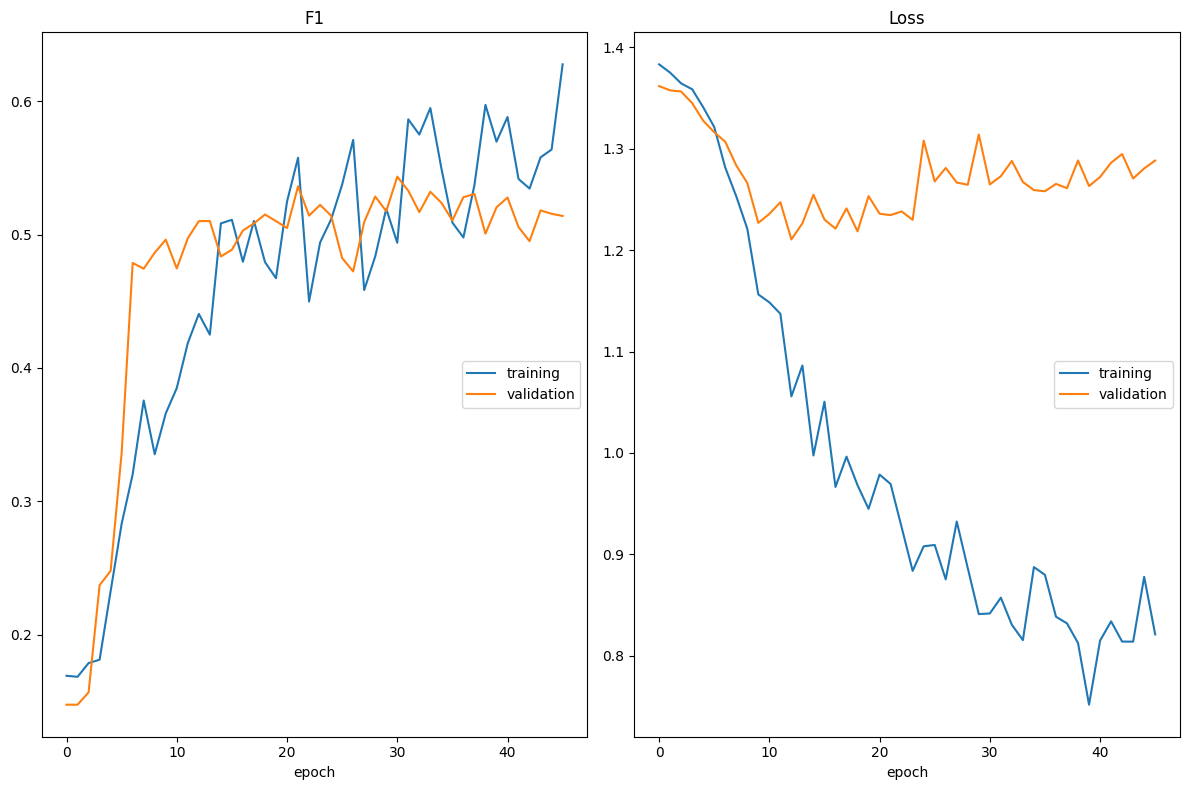

Ep  46/60  loss=0.8210  val_loss=1.2885  F1=0.6275  val_F1=0.5139  AUC=0.7575
Early stopping ep 46. Melhor: 31, F1=0.5434
Fase concluída – melhor val F1: 0.5434
Tempo fase 2: 497.1s


In [39]:
model.load_state_dict(torch.load(model_name))
for param in model.parameters():
    param.requires_grad = True
print(f'Backbone descongelado. Parâmetros: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

opt2 = torch.optim.AdamW(model.parameters(), lr=LR_P2, weight_decay=1e-4)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_P2, eta_min=1e-7)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt2, sch2, EPOCHS_P2, model_name,
            patience=PATIENCE, use_mixup=True,
            phase_name='Fase2_FineTuning')
print(f'Tempo fase 2: {time.perf_counter()-t0:.1f}s')

## 8. Avaliação no Conjunto de Teste

In [40]:
model.load_state_dict(torch.load(model_name))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

f1  = f1_score(all_labels, all_preds, average='macro')
acc = accuracy_score(all_labels, all_preds)

print(f'\n{"="*55}')
print(f' Accuracy  : {acc:.4f}')
print(f' F1-macro  : {f1:.4f}')
print(f' Baseline  : 0.7380')
print(f' Delta     : {f1-0.738:+.4f}')
print(f'{"="*55}\n')
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4, zero_division=0))


 Accuracy  : 0.6629
 F1-macro  : 0.5558
 Baseline  : 0.7380
 Delta     : -0.1822

               precision    recall  f1-score   support

Biliary_Leaks     0.5000    0.1765    0.2609        17
    Lithiasis     0.6643    0.7724    0.7143       123
       Normal     0.5455    0.5581    0.5517        43
    Stricture     0.7432    0.6548    0.6962        84

     accuracy                         0.6629       267
    macro avg     0.6133    0.5404    0.5558       267
 weighted avg     0.6596    0.6629    0.6535       267



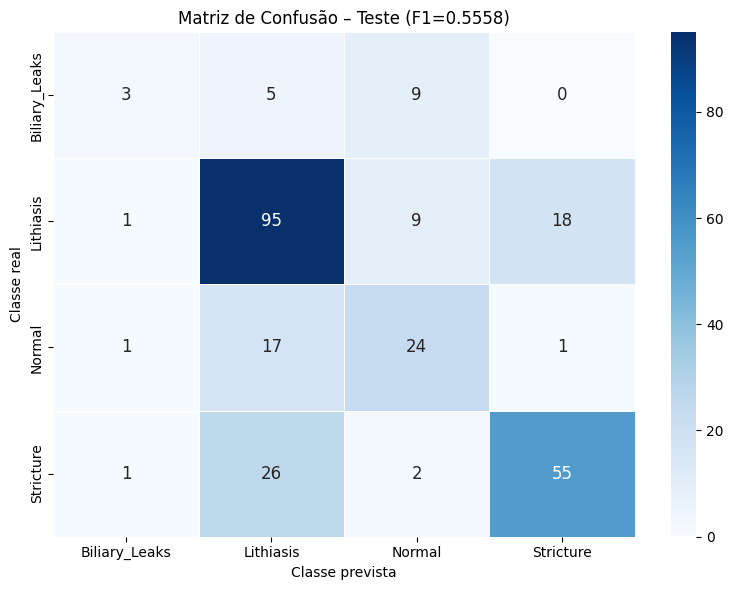

In [41]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real'); plt.xlabel('Classe prevista')
plt.title(f'Matriz de Confusão – Teste (F1={f1:.4f})')
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix.png', dpi=200)
plt.show()

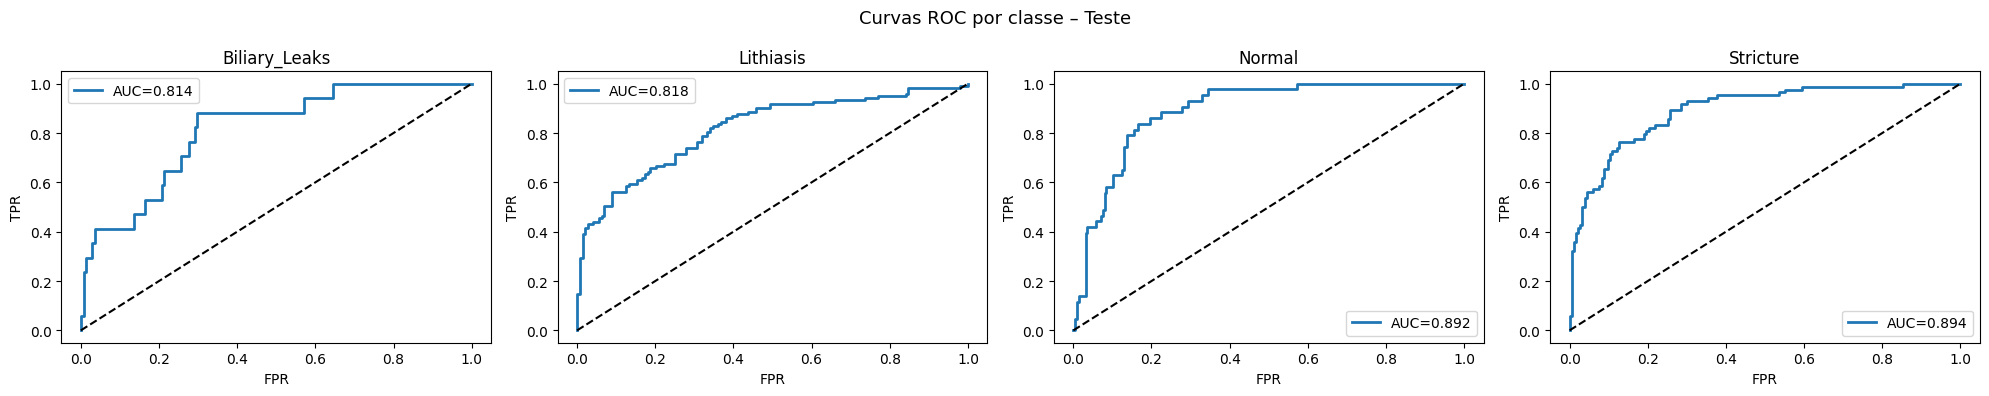

AUC-ROC macro (OvR): 0.8548


In [42]:
y_bin = label_binarize(all_labels, classes=np.arange(num_class))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--'); ax.set_title(cname)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.suptitle('Curvas ROC por classe – Teste', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()
mean_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

## 9. Grad-CAM

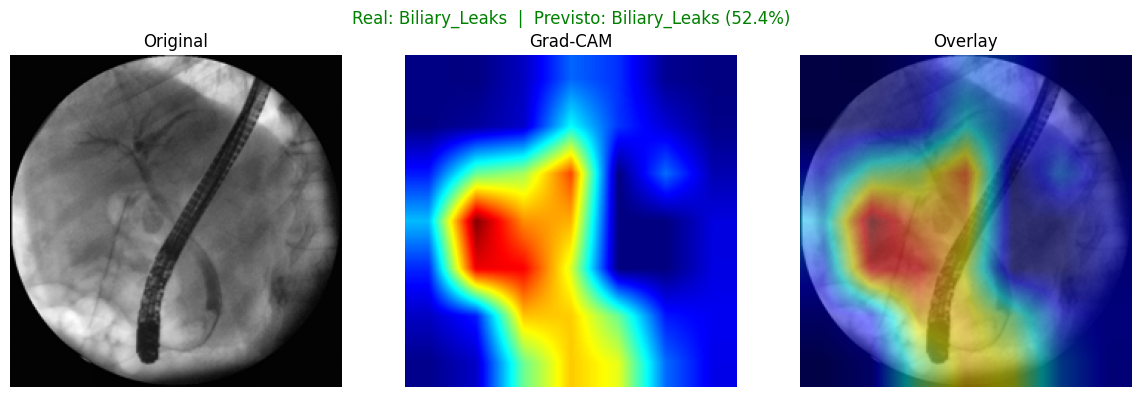

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


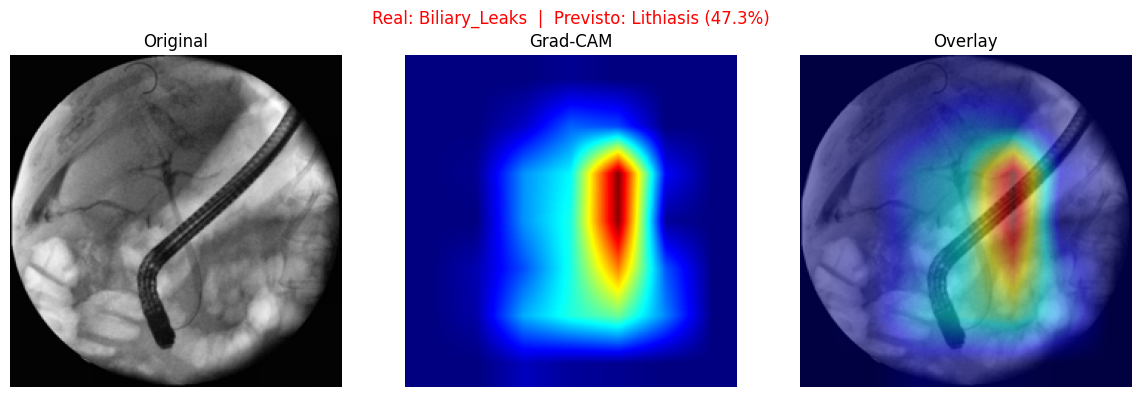

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


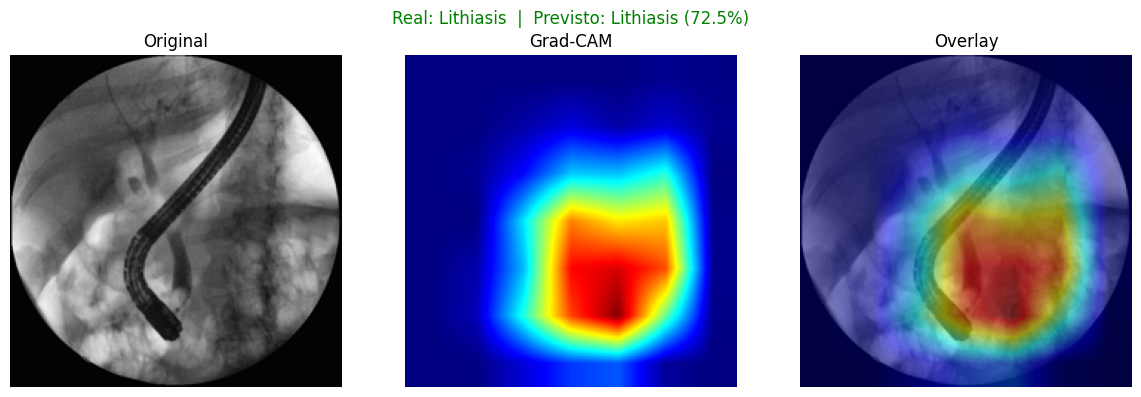

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


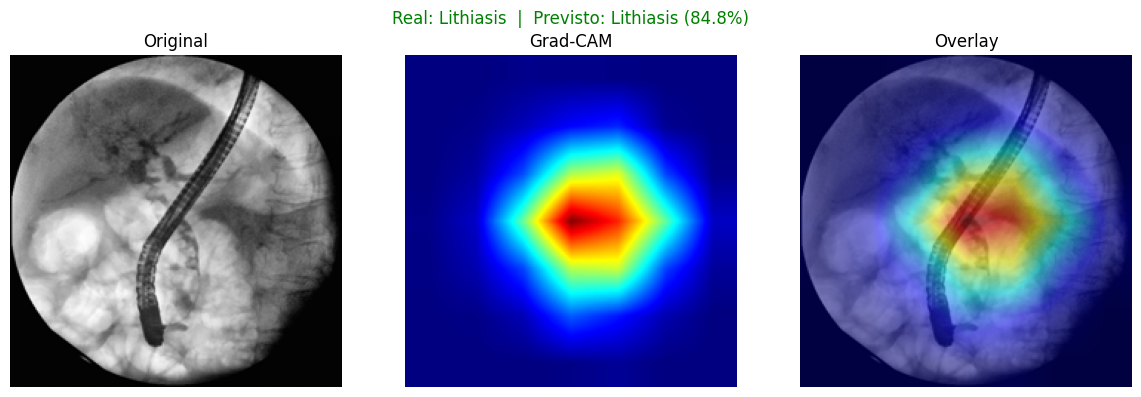

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


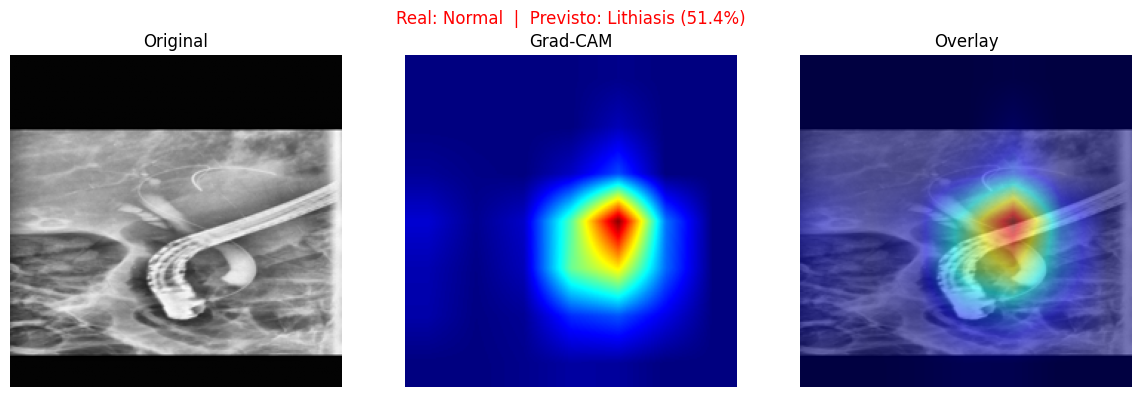

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


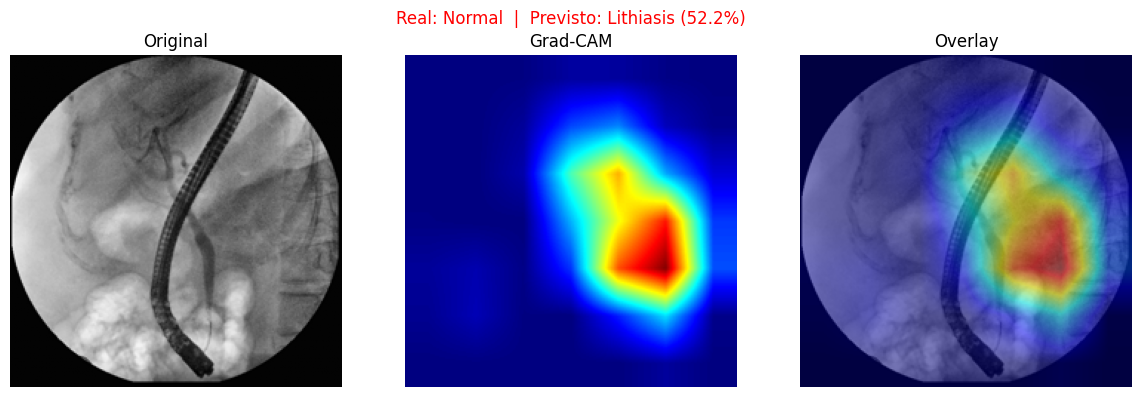

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


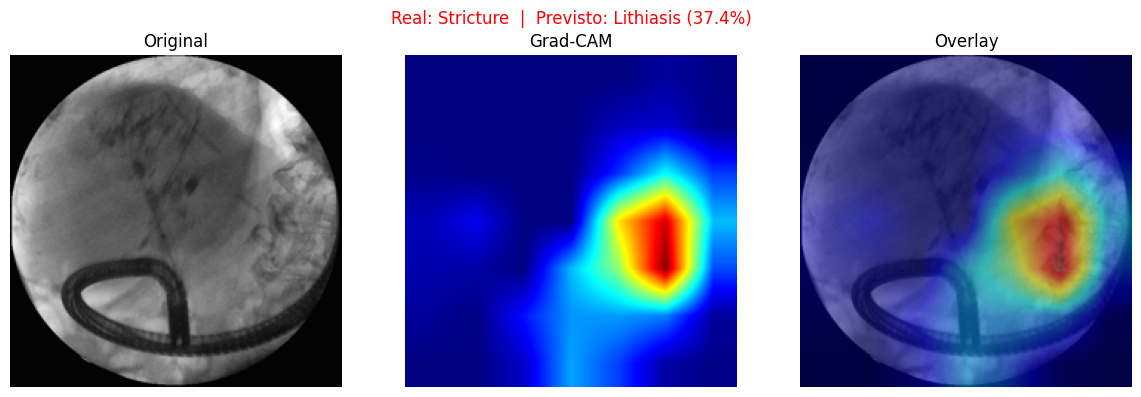

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


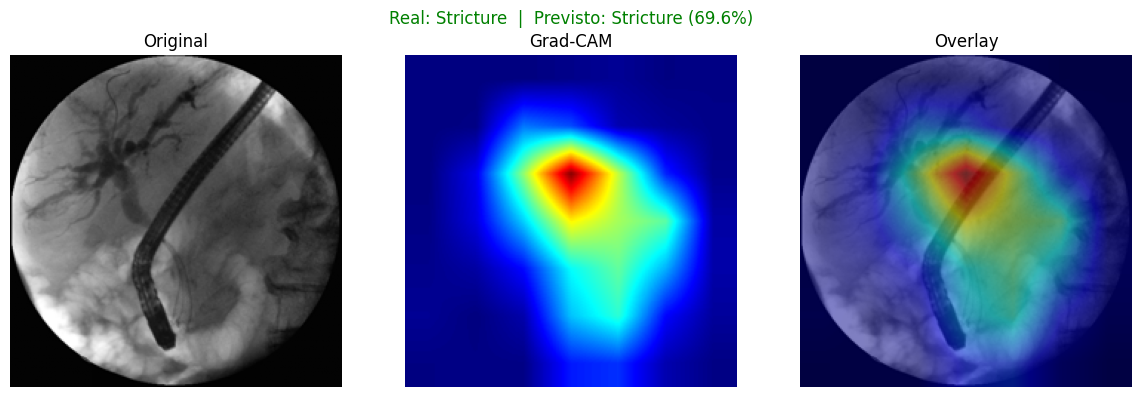

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [43]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x   = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, F.softmax(out, dim=1)[0, class_idx].item()


gradcam = GradCAM(model, target_layer=model.features[-1])

def show_gradcam(img_path, true_label, save_path=None):
    img_tensor = val_transforms(img_path)
    cam, pred_idx, prob = gradcam.generate(img_tensor)
    raw     = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*raw_rgb + 0.5*heatmap).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
                 fontsize=12, color=cor)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(p,l) for p,l in zip(data['test']['images'], data['test']['labels']) if l == ci]
    for k, (path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

In [44]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v4 (grayscale x3, MONAI)  test F1 = 0.5558  <- base')
print(f'  v8 (RGB + ImageNet norm)  test F1 = {f1:.4f}')
print(f'  Baseline artigo                    = 0.7380')
print(f'  Delta vs baseline                  = {f1-0.738:+.4f}')
print('='*60)


RESUMO COMPARATIVO
  v0 (professor, CPU)  test F1 = 0.4564
  v1 (CPU)             test F1 = 0.4973
  v2 (GPU, colapso)    test F1 = 0.3063
  v3 (GPU, corrigido)  test F1 = (ver v3)
  v4 (GPU, CLAHE off.) test F1 = 0.5558
  Baseline artigo              = 0.7380
  Delta vs baseline            = -0.1822
